## Exploratory Data Analysis

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
df = pd.read_csv('data/skinport_items_cleaned(1).csv')
print(df.shape)
df.head()

(1445, 10)


,weapon,skin_name,condition,min,max,avg,median,volume,souvenir,stat_trak
0,AK-47,Steel Delta,2,4.06,8.61,5.35,4.87,7,1,0
1,AK-47,Black Laminate,1,58.03,58.03,58.03,58.03,1,0,0
2,AK-47,Aquamarine Revenge,0,27.33,35.98,32.02,31.67,7,0,0
3,AK-47,Fire Serpent,4,2485.40,2625.52,2555.46,2555.46,2,0,0
4,AK-47,Predator,0,9.23,9.68,9.46,9.45,2,0,0


---

## Summary statistics

---

In [52]:
# quick overview of numeric variables

df[['min', 'max', 'avg', 'median', 'volume']].describe().round(2)

,min,max,avg,median,volume
count,1445.00,1445.00,1445.00,1445.00,1445.00
mean,206.92,272.99,228.27,225.25,40.81
std,868.98,932.84,895.29,894.40,72.11
min,0.02,0.03,0.02,0.02,1.00
25%,5.86,13.92,8.19,7.79,4.00
50%,29.78,56.11,37.49,35.93,13.00
75%,102.64,181.07,126.03,119.76,44.00
max,15726.81,15726.81,15726.81,15726.81,768.00


## Average price by condition

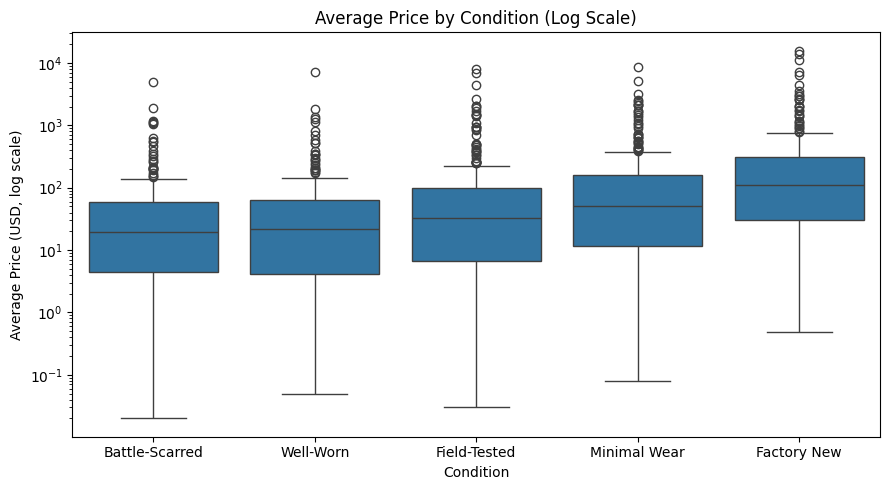

In [53]:
condition_labels = {
    0: 'Battle-Scarred', 
    1: 'Well-Worn', 
    2: 'Field-Tested', 
    3: 'Minimal Wear', 
    4: 'Factory New'
}

df['condition_label'] = df['condition'].map(condition_labels)
df = df.dropna(subset=['condition_label'])
cond_order = ['Battle-Scarred', 'Well-Worn', 'Field-Tested', 'Minimal Wear', 'Factory New']

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='condition_label', y='avg', order=cond_order, ax=ax)
ax.set_yscale('log')
ax.set_title('Average Price by Condition (Log Scale)')
ax.set_xlabel('Condition')
ax.set_ylabel('Average Price (USD, log scale)')
plt.tight_layout()
plt.show()

## Price Premium: StatTrak™ and Souvenir

StatTrak™ skins track kill counts and typically sell at a premium. Souvenir skins are tournament drops and tend to have different pricing dynamics. We compare median average prices across these categories.

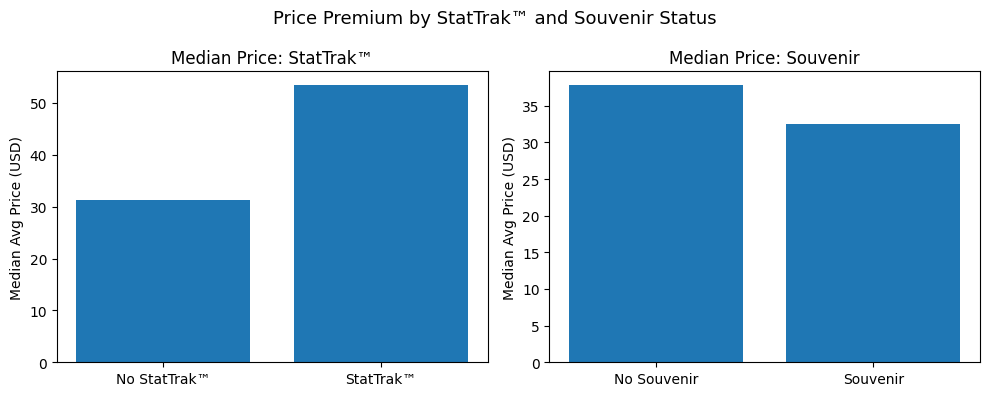

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, label in zip(axes, ['stat_trak', 'souvenir'], ['StatTrak™', 'Souvenir']):
    medians = df.groupby(col)['avg'].median()
    ax.bar([f'No {label}', label], [medians.get(0, 0), medians.get(1, 0)])
    ax.set_title(f'Median Price: {label}')
    ax.set_ylabel('Median Avg Price (USD)')

plt.suptitle('Price Premium by StatTrak™ and Souvenir Status', fontsize=13)
plt.tight_layout()
plt.show()

## Sales Volume by Weapon

Sales volume reflects market liquidity. Higher volume indicates more actively traded skins.

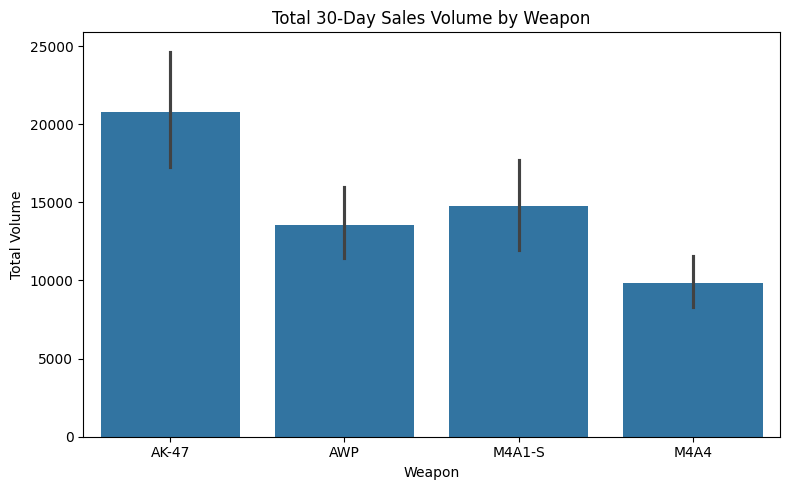

In [55]:
weapon_order = df.groupby('weapon')['avg'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df, x='weapon', y='volume', order=weapon_order,
            estimator='sum', ax=ax)
ax.set_title('Total 30-Day Sales Volume by Weapon')
ax.set_xlabel('Weapon')
ax.set_ylabel('Total Volume')
plt.tight_layout()
plt.show()

## Correlation Heatmap

We examine pairwise correlations among numeric variables. Strong correlation between `min`, `max`, `avg`, and `median` is expected. The relationship between `condition` and price is of primary interest.

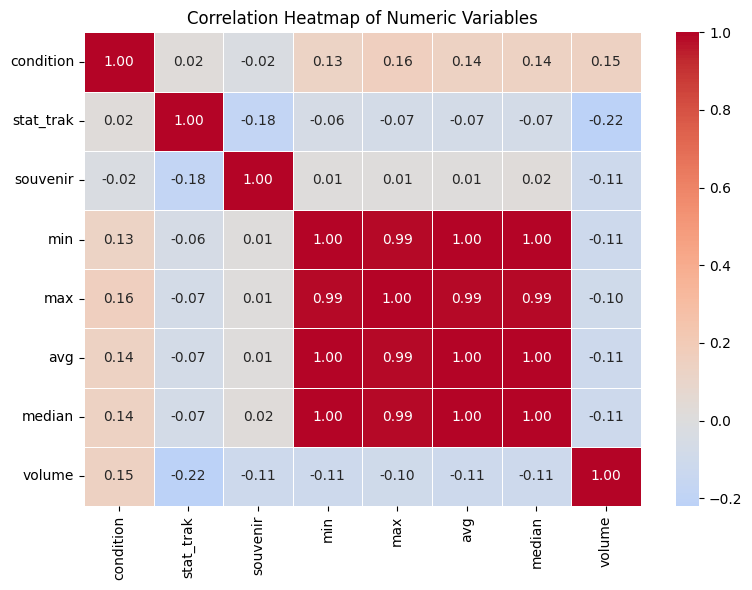

In [56]:
numeric_cols = ['condition', 'stat_trak', 'souvenir', 'min', 'max', 'avg', 'median', 'volume']
corr = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()

## Top 10 Most Expensive Skins

We identify the ten skins with the highest median average price over the past 30 days.

In [58]:
top10 = (
    df.groupby(['weapon', 'skin_name'])['avg']
    .median()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top10.columns = ['Weapon', 'Skin', 'Median Avg Price (USD)']
top10['Median Avg Price (USD)'] = top10['Median Avg Price (USD)'].round(2)
top10

,Weapon,Skin,Median Avg Price (USD)
0,AK-47,Wild Lotus,15726.81
1,AWP,Gungnir,8099.76
2,AWP,Dragon Lore,7729.65
3,M4A4,Howl,5172.45
4,M4A1-S,Knight,2984.14
5,AWP,The Prince,2627.38
6,AK-47,Hydroponic,2083.46
7,M4A1-S,Hot Rod,2026.25
8,AWP,Medusa,1885.20
9,M4A1-S,Imminent Danger,1767.19
